In [1]:
# Make repo root importable for this session (zero packaging)
import sys, pathlib
repo_root = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == "notebooks") else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from rnencodec.utils.utils import param_breakdown
from rnencodec.utils.io import save_run_config

from rnencodec.audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset_constant, EnCodecLatentDataset_dynamic, EnCodecLatentDataset_dynamic_v2, EnCodecLatentDataset_dynamic_v3, latents_to_audio_simple
from torch.utils.data import DataLoader

import rnencodec.model.gru_audio_model
from rnencodec.model.gru_audio_model import GRUModelConfig

from transformers import EncodecModel

import torch.nn.functional as F

<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>
<b>Data sets</b>

The syn7wav24_tokens_HFdataset_5 has the following parameters:   
&nbsp;&nbsp;&nbsp;&nbsp;        ['Full File Name', 'class_name', 'param1', 'param2', 'param3', 'param0', 'audio']  
and the following unique 'class_name' values:  
&nbsp;&nbsp;&nbsp;&nbsp;        Class list: ['ChirpPattern', 'DSApplause', 'DSBugs', 'DSPeepers', 'DSPistons', 'DSWind', 'TokWotalDuet']  
which you can use to filter the full dataset if you only want to train on a subset of sound classes, for example:  
&nbsp;&nbsp;&nbsp;&nbsp;        config.filters = {'class_name': {'DSPistons', 'DSApplause'}}  
<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>

### Data Params  
<a id="dataparams"></a>

These parameters are saved to file, and serve several purposes:
* The allow other programs to properly evaluate and visualize the trained (and also saved) models,
* Provide a record of the parameters that allow reproducing results. 

In [3]:
resume_checkpoint= None 
resume_checkpoint  = str(Path('output/20260123_114246_engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_newprep'))

dataset="enginesC" # "ddsp_violin"

if dataset=="syntex": # syntex #about 8 hours of audio for each class!
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5' )  # where the data files live
    savename="multiclass_test_HARDcascade" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"c1": (0, 1), "c2": (0, 1),"c3": (0, 1),"c4": (0, 1),"c5": (0, 1),"c6": (0, 1),"c7": (0, 1),"param1": (0,1)}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='val'
    EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file
    

if dataset=="syntex_new": # uses the new data format and v3 data loader 
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/syn7_v4/hf_dataset' )  # where the data files live
    savename="datapreptest_dynamic_25" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"param1": None, "class_ChirpPattern": None, "class_DSApplause": None,"class_DSBugs": None,"class_DSPeepers": None,"class_DSPistons": None,"class_DSWind": None,"class_TokWotalDuet": None}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='validation'
    #EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic

elif dataset=="nsynth" : # nsynth
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/MuMeRNN/data/nsynth.64.76.ecdc24HF' )  # where the data files live
    savename="nsynth_soft_cascade"  #just a tag on the output folder 
    props={"class": (.0,1),"norm_pitch": (-.05,1.05), "norm_amp": (0,1),} #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'
    EnCodecLatentDataset=EnCodecLatentDataset_constant   #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="water":  #15 minutes of sound
    sourcedatadir = os.path.join(repo_root, 'artifacts/data/waterfill_quickstart_hf_dataset' )  # where the data files live
    savename="water_soft.35"  #just a tag on the output folder 
    props={"pos": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


elif dataset=="ddsp_violin":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/DDSP_ViolinSet2/ddsp_violinset_hf' )  # where the data files live
    savename="ddsp_violin_seql_75_corrected"  #just a tag on the output folder 
    props={"pitch": None, "amp": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="babble_gender":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/estaban_babble_gender/dataset_hf' )  # where the data files live
    savename="babble_gender_mf"  #just a tag on the output folder 
    props={"sex": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="nsynth7": # 1.5 minutes per instrument, 11 minutes of sound
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/NSynth/nsynth_7_glide_HF' )  # where the data files live
    savename="nsynth7_trial2"  #just a tag on the output folder 
    props={"pitch": None, "velocity": None, "003clarinet": None, "006frenchhorn": None,"094bass": None,"162flute": None,"272voice-ee": None,"295voice-oo": None,"887organ": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="enginesC":
    #sourcedatadir = os.path.join(repo_root, '/slowdisk/data/ProceduralEngineSounds/ECDC/C_full_set_ecdc_HF')
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/ProceduralEngineSounds/CSV/proceduralengine_prepped/hf_dataset')
    savename="engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_newprep"  #just a tag on the output folder 
    props={"RPM": None, "Torque": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train' 
    val_split='test'
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


print(f'props are {props}')
rawqweights=torch.tensor([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3], dtype=torch.float)

params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 25, #10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 50, # 225, # #20, # of batches_per_epoch of batch_size sequeunce (if resuming, this is how many *more* epochs to do.
    batches_per_epoch = 100, #100, 
    batch_size = 100, #100, 
    
    noise=.05,
    seqLen = 100, #75, #14379, # 125, # 125,

    lr = 0.005,
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters -----------------
    input_size = 128,
    hiddenSize = 128, # 128, #100,
    nLayers = 3,
    inp_proportion = 5,
    cond_proportion = 2,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = 8,                                # Number of codebooks to use
    quantizer_weights = rawqweights * (len(rawqweights) / rawqweights.sum()), #normed to sum to the length of the array
    clamp_val = 15,


    # training-time knobs you already have (not used yet)
    gumbel_tau_start = 1.0,
    gumbel_tau_end = 0.5,
    straight_through = True,

    # cascade selection
    cascade = "soft",  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = "sample",
    top_n_hard = 3,   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = 1.0,
    
    # SOFT cascade knobs (RNG-free unless you later add gumbel-soft)
    tau_soft = 0.35, #[peaky, .6, smoother]
    top_n_soft = 8,  # optional sparse softmax (still deterministic)

    # ----------------------------
    simulate_parallel = False,  #Simultate parallel will turn TF on and send 0's in to simulate no cascading information

    # Training parameters
    files_per_sequence=2, #important - how many different data files to draw from to create each sequence. For short seq_lens, and dynamic params, this should probably be 1
    TF_schedule = [25,25], # cycle: [TF batches, noTF batches] (make sure simulate_parallel is False if you want TF

)

# for managing the switching between TF and no TF
TF_cycle=params['TF_schedule'][0]+params['TF_schedule'][1]
use_tf = lambda epoch: (epoch % TF_cycle) < params['TF_schedule'][0]  # ['TF_schedule'][0]  on, ['TF_schedule'][1] off
#use_tf = lambda epoch: True #true means Always use no TF (first part of "cycle")

props are {'RPM': None, 'Torque': None}


In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2026-01-23_13-43-46',
 'datadir': '/slowdisk/data/ProceduralEngineSounds/CSV/proceduralengine_prepped/hf_dataset',
 'filters': {},
 'savemodel': True,
 'savemodel_interval': 25,
 'savemodeldir': '/home/lonce/working/RNeNcodec/notebooks/output',
 'num_epochs': 50,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.05,
 'seqLen': 100,
 'lr': 0.005,
 'props': {'RPM': None, 'Torque': None},
 'input_size': 128,
 'hiddenSize': 128,
 'nLayers': 3,
 'inp_proportion': 5,
 'cond_proportion': 2,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 8,
 'quantizer_weights': tensor([1.5385, 1.3846, 1.2308, 1.0769, 0.9231, 0.7692, 0.6154, 0.4615]),
 'clamp_val': 15,
 'gumbel_tau_start': 1.0,
 'gumbel_tau_end': 0.5,
 'straight_through': True,
 'cascade': 'soft',
 'hard_sample_mode': 'sample',
 'top_n_hard': 3,
 'temperature_hard': 1.0,
 'tau_soft': 0.35,
 'top_n_soft': 8,
 'simulate_parallel': False,
 'files_per_sequence': 2,
 'TF_schedule': [25, 25]}

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cuda', index=0)

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



In [7]:

#--- model settings ----#
model_config = GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q'],

    inp_proportion = params['inp_proportion'],
    cond_proportion = params['cond_proportion'],

    # training-time knobs you already have (not used yet)
    gumbel_tau_start = params['gumbel_tau_start'],
    gumbel_tau_end = params['gumbel_tau_end'],
    straight_through = params['straight_through'],

    # cascade selection
    cascade = params['cascade'],  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = params['hard_sample_mode'],
    top_n_hard = params['top_n_hard'],   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = params['temperature_hard'],

    tau_soft = params['tau_soft'],
    top_n_soft = params['top_n_soft'],  # optional sparse softmax (still deterministic)

)

    

# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=4,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split=val_split)
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=4,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

✅ Configuration and model loaded
[EnCodecLatentDataset] No filters provided; using all 700 rows.
Loaded 570014 sequences from 700 files in 'train' split
[EnCodecLatentDataset] No filters provided; using all 67 rows.
Loaded 55321 sequences from 67 files in 'test' split
size of dataset is 570014
no. of batches per epoch is 100
batchsize id  is 100


size of dataset is 570014
no. of batches per epoch is 100
batchsize id  is 100
PVECT - shape is torch.Size([100, 2])
pvect[0]: tensor([0.2354, 0.2102])
pvect[25]: tensor([0.2352, 0.2087])
pvect[last]: tensor([0.4289, 0.5313])
inp.shape is torch.Size([100, 128])


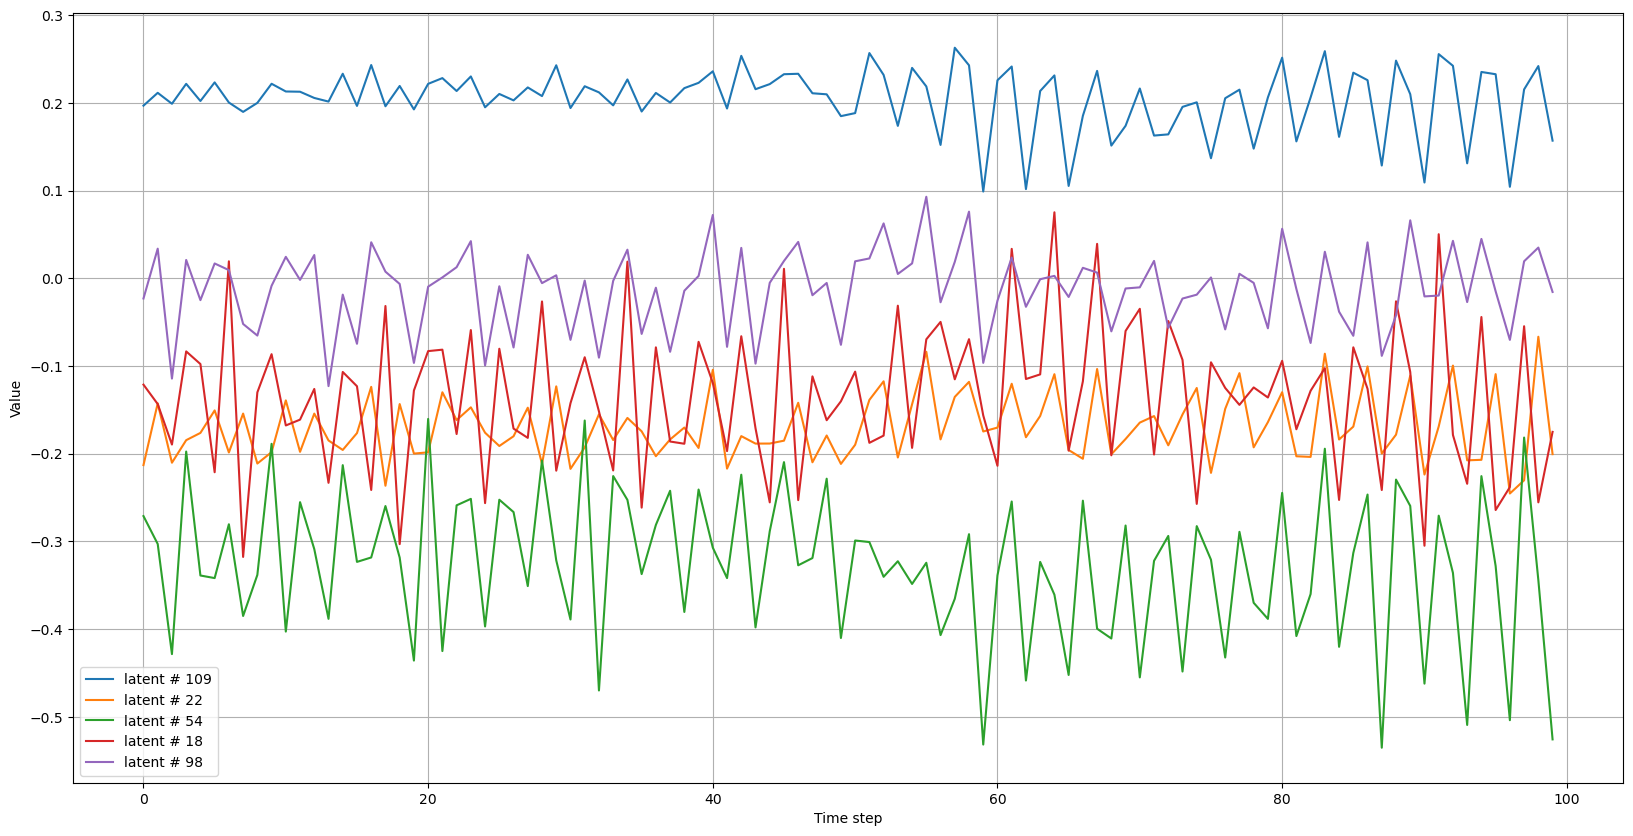

SHAPE: torch.Size([1, 128, 100])


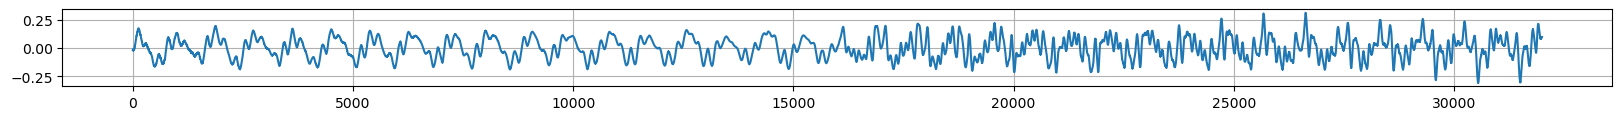

conditioning.shap = torch.Size([100, 2])


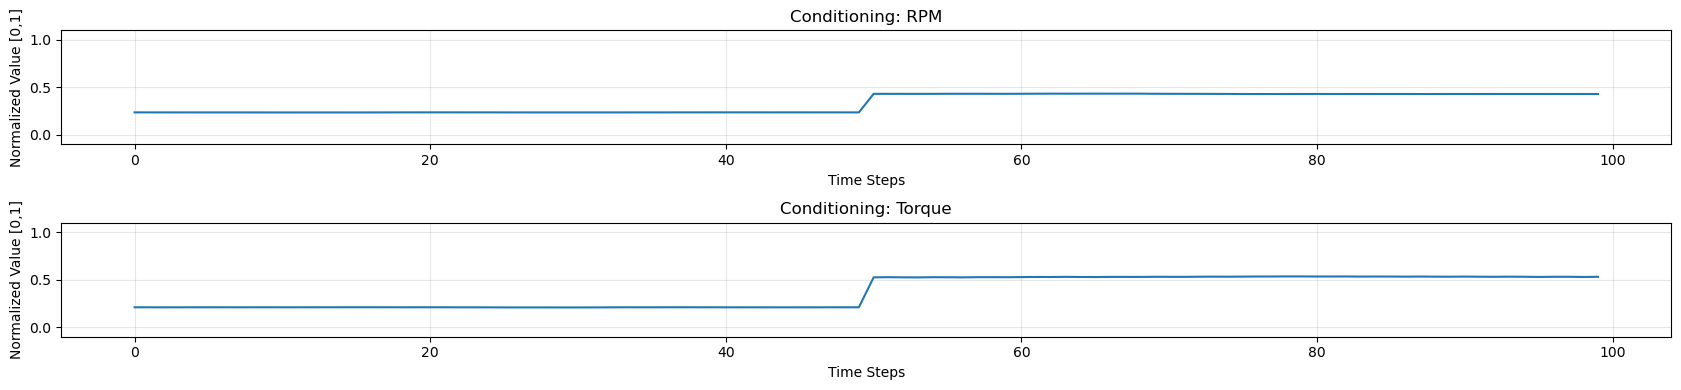

In [8]:
# just show some stuff 
def pmap(x) :
    return 55+x*(88-55)

print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

samp, target = adataset.rand_sample()  #samp.shape=(T, inputsize+cond_size)
pvect=samp[:, -model_config.cond_size:]
print(f'PVECT - shape is {pvect.shape}')
pvect0=samp[0, -model_config.cond_size:]
print(f"pvect[0]: {pvect0}")
pvect25=samp[25, -model_config.cond_size:]
print(f"pvect[25]: {pvect25}")
pvectl=samp[params['seqLen']-1, -model_config.cond_size:]
print(f"pvect[last]: {pvectl}")

inp=samp[:,:-model_config.cond_size]
print(f'inp.shape is {inp.shape}')

# Now grab n=10 random latent components and look at them over time
_, p = inp.shape
# Generate n=10 random indices from 0 to p-1
indices = torch.randperm(p)[:5]
sub_inp = inp[:, indices]
sub_inp.shape


#first print latent sequence
plt.figure(figsize=(20,10)) 
# plt.plot(np.arange(len(sub_inp)), sub_inp) #just print some example from the batch
# plt.grid()
# plt.show()

ts = np.arange(len(sub_inp))  # time steps
for i in range(sub_inp.shape[1]):   # loop over trajectories
    plt.plot(ts, sub_inp[:, i], label=f"latent # {indices[i]}")
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid()
plt.show()



tokens=samp[:, :params['input_size']].T.unsqueeze(0)
print(f"SHAPE: {tokens[:,:params['input_size']].shape}")
audiosamps, sr=latents_to_audio_simple(enc_model, tokens*params['clamp_val'])
audiosamps=audiosamps[0, 0]

plt.figure(figsize=(20,1)) 
plt.plot(audiosamps) #just print one example from the batch
plt.grid()
plt.show()


#conditioning = samp[:,-model_config.cond_size:]
cvect = pvect#=samp[:, -model_config.cond_size:] # samp[:, -model_config.cond_size:].squeeze(0)  #imp_seq[0, :, -len(params['props']):]
n_params = cvect.shape[1]
print(f'conditioning.shap = {cvect.shape}')
# # Additional Analysis: Conditioning parameters over time
if n_params > 0:
    plt.figure(figsize=(17, 4))
    
    param_names = list(data_config.parameter_specs.keys())
    
    for i in range(n_params):
        plt.subplot(2, (n_params + 1) // 2, i + 1)
        plt.plot(cvect[:,i].numpy())
        param_name = param_names[i] if i < len(param_names) else f'param_{i}'
        plt.title(f'Conditioning: {param_name}')
        plt.xlabel('Time Steps')
        plt.ylabel('Normalized Value [0,1]')
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()

    # #print out numbers
    # cvect_mapped = torch.stack([pmap(cvect[:, 0]), cvect[:, 1]], dim=1)
    # print(f"conditioning params: {cvect_mapped}")

#Another check just to see that the ecdc and params are coming from the same file and using the same starting sample number (no using the random sample as above)
# entry = adataset.sequence_map[0]         # (dataset_idx, start_frame, token_file_path)
# ds_idx, start, token_path = entry
# cpath = adataset._cond_path_for(token_path)
# print("codes:", token_path.name, "cond:", cpath.name, "start:", start)


#This is the "rand_samp" plotted above"
Audio(audiosamps, rate=params['sample_rate'])

In [9]:

def prepare_target_codebook_latents(rnn_model, target_codes, scales_bq=None):
    """
    target_codes: (B, n_q) LongTensor for a single timestep
    returns: List[n_q] of (B, D=128) latents, one per codebook (level 0..n_q-1)
    """
    dev = rnn_model._E_eff.device
    codes_bq = target_codes.to(dev, dtype=torch.long, non_blocking=True)
    if scales_bq is not None:
        scales_bq = scales_bq.to(dev, non_blocking=True)

    out = []
    for q in range(rnn_model.n_q):
        E_q = rnn_model._E_eff[q]                    # (K, D)
        e_q = F.embedding(codes_bq[:, q], E_q)       # (B, D)
        if scales_bq is not None:
            e_q = e_q * scales_bq[:, q].unsqueeze(-1)
        out.append(e_q)
    return out

In [10]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,encodec_model, epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = 0
    
    # Initialize per-quantizer loss tracking
    quantizer_losses = [0.0] * params['n_q']
    
    # Define quantizer weights
    quantizer_weights = params['quantizer_weights'][:params['n_q']]
     
    for i in range(params['seqLen']):  # causal: one time step at a time
        if params['simulate_parallel']:
            use_teacher_forcing = True
            # just placeholders for shape when sim-parallel; zeros are fine
            tflatents = [torch.zeros(params['batch_size'], params['input_size'], device=device)
                         for _ in range(params['n_q'])]
        else:
            use_teacher_forcing = use_tf(epoch)
            if use_teacher_forcing:
                # prepare ground-truth per-level latents (List[n_q * (B,128)])
                tflatents = prepare_target_codebook_latents(model, target[:, i, :]) # uses model's decoder
            else:
                tflatents = None
    
        # --- ONE call; ONE set of sampled tokens used everywhere ---
        logits_list, hidden, sampled_indices, step_latent = model(
            inp[:, i, :],
            hidden,
            target_codebook_latents=tflatents,
            use_teacher_forcing=use_teacher_forcing,
            return_step_latent=False, # this is for "self conditioning"

        )
    
        # --- CE loss exactly as before (per-quantizer) ---
        for j in range(params['n_q']):
            quantizer_loss = criterion(logits_list[j], target[:, i, j])
            quantizer_losses[j] += quantizer_loss.item()
            loss = loss + quantizer_weights[j] * quantizer_loss
    
        # # --- Self-conditioning for next step: feed SAME latent forward ---
        # if i + 1 < params['seqLen']:
        #     # step_latent is:
        #     #  - the sum of teacher-forced per-level latents if TF,
        #     #  - the sum of decoded sampled tokens if AR.
        #     # Use .detach() for stable training (no across-time grads for now).
        #     inp[:, i + 1, :params['input_size']] = step_latent.detach()
    
    loss = loss / params['seqLen']
    quantizer_losses = [ql / params['seqLen'] for ql in quantizer_losses]
    
    loss.backward()
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    #ave_loss_over_steps += ave_loss_per_sample
    
    # Accumulate quantizer losses over the epoch
    if batch_num == 0:  # Initialize on first batch
        epoch_quantizer_losses = [0.0] * params['n_q']
    
    for j in range(params['n_q']):
        epoch_quantizer_losses[j] += quantizer_losses[j]
    
    if batch_num>=(params['batches_per_epoch']-1):
        break


    per_q_time_mean = [s / params['seqLen'] for s in quantizer_losses]  # each is batch-mean, time-mean
    overall_time_mean = float(torch.dot(quantizer_weights, torch.tensor(per_q_time_mean, device=quantizer_weights.device)).item())

    
 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")
 if (epoch+1) % log_interval == 0:
    print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
    list_of_losses.append(ave_loss_per_sample)
    writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)
    writer.add_scalar("overall_time_mean", overall_time_mean, epoch+1)
    
    # Log individual quantizer losses (averaged over the epoch)
    num_batches = min(batch_num + 1, params['batches_per_epoch'])
    for j in range(params['n_q']):
        avg_quantizer_loss = epoch_quantizer_losses[j] / num_batches
        writer.add_scalar(f"Loss/quantizer_{j}", avg_quantizer_loss, epoch+1)
        print(f"  Quantizer {j} Loss: {avg_quantizer_loss:.4f}")

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [11]:
# ---- Create Output Folders ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)


# # ---- Save Config ----
# #machine readable
# torch.save({
#     "model_config": model_config,
#     "data_config": data_config
# }, f"{out_dir}/config_v1.pt")


# #human readable
# with open(f"{out_dir}/config_v1.txt", "w") as f: 
#     f.write("params = " + repr(params) + "\\n")
#     f.write("model_config = " + repr(model_config) + "\\n")
#     f.write("data_config = " + repr(data_config) + "\\n")

#This can replace the above 2 torch.save calls 
save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
print(f"wrote {out_dir}/config_v2.pt")

saved to output/20260123_114246_engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_newprep/config_v2.pt
wrote json param file
wrote output/20260123_114246_engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_newprep/config_v2.pt


In [12]:
import copy
from rnencodec.generator import RNNGenerator

inference_model_config=copy.deepcopy(model_config)
inference_model_config.cascade='hard' # 
inference_model_config.hard_sample_mode="sample"
inference_model_config.top_n_hard=12
inference_model_config.temperature_hard=1.0


def newgen(model,max_length):
    #This hack allows us to "configure" the model for generation differently - in particular how it is sampled (which may be different from how it is trained)
    inference_model = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to('cpu')
    inference_model.load_state_dict(model.state_dict())

    #override these values of state
    inference_model.cascade='hard' # 
    inference_model.hard_sample_mode="sample"
    inference_model.top_n_hard=12
    inference_model.temperature_hard=1.0



    rnninference=RNNGenerator(inference_model, inference_model_config, testdata_config, enc_model, max_length, max_length)
    
    # grab a random conditioning vector from the data set
    p_inp, _ = next(iter(test_loader)) # don't need targets
    c = p_inp[:, 0, -inference_model_config.cond_size:].squeeze(0).to(device) #grab a random input sequence
    print(f'DEVICE going in: model tensors {next(model.parameters()).device}, enc_model {enc_model.device}, c {c.device}')
    print(f'About toInitialize generator with c.shape = {c.shape}') 
    rnninference.warmup(c,10)
    gen = rnninference.getNextAudioHop(c, hop=max_length)
    
    return gen

In [13]:
inference_model_config

GRUModelConfig(input_size=128, cond_size=2, hidden_size=128, num_layers=3, n_q=8, codebook_size=1024, dropout=0.1, inp_proportion=5, cond_proportion=2, gumbel_tau_start=1.0, gumbel_tau_end=0.5, straight_through=True, cascade='hard', hard_sample_mode='sample', top_n_hard=12, temperature_hard=1.0, tau_soft=0.35, top_n_soft=8)

### Load the model 

In [14]:

rnn = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to(device)
    
optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
criterion = nn.CrossEntropyLoss(reduction='mean')

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
Resumed from checkpoint at epoch 26


/home/lonce/micromamba/envs/testing2/lib/python3.11/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5090 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5090 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(
/tmp/ipykernel_1182091/350502810.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that cou

In [15]:
num_trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_trainable_params}")

bd = param_breakdown(rnn, trainable_only=True) #prints out a breakdown of the parameter counts per layter
# pretty print
print(f"latent_proj: {bd['latent_proj']:,}")
print(f"cond_proj:   {bd['cond_proj']:,}")
print(f"GRU total:   {bd['gru_total']:,}")
for k, v in bd['gru_layers'].items():
    print(f"  {k}: {v:,}")
print("Decoders (per head):")
for i, n in enumerate(bd['decoders']):
    print(f"  decoder[{i}]: {n:,}")
print(f"Decoders total: {bd['decoders_total']:,}")
print(f"Model total:    {bd['model_total']:,}")


n_q, K, D = rnn._E_eff.shape
print(f"✅ E_eff is built: n_q={n_q}, K={K}, D={D}, device={rnn._E_eff.device}")
# per-level shapes (each should be (K, D))
print("Per-level shapes:", [tuple(rnn._E_eff[q].shape) for q in range(n_q)])


# 1) Make sure both models are on the same device
device = next(rnn.parameters()).device
enc_model = enc_model.to(device)

B, T = 4, 7
codes = torch.randint(0, rnn.codebook_size, (B, T, rnn.n_q), device=device, dtype=torch.long)

# 3) Manual path via cached effective tables (matches Encodec exactly)
z_manual = rnn._codes_to_latent_sum(codes)                           # (B, T, D)

# 4) Encodec path (expects (n_q, B, T))
z_decode = enc_model.quantizer.decode(codes.permute(2, 0, 1))        # (B, D, T)
z_decode = z_decode.permute(0, 2, 1).contiguous()                    # (B, T, D)

# 5) Compare
diff = (z_manual - z_decode).abs()
print("DIFFERENCE — max|Δ|=", diff.max().item(), "mean|Δ|=", diff.mean().item())

Total trainable parameters: 2414410
latent_proj: 11,739
cond_proj:   111
GRU total:   297,216
  l0/fwd: 99,072
  l1/fwd: 99,072
  l2/fwd: 99,072
Decoders (per head):
  decoder[0]: 263,168
  decoder[1]: 263,168
  decoder[2]: 263,168
  decoder[3]: 263,168
  decoder[4]: 263,168
  decoder[5]: 263,168
  decoder[6]: 263,168
  decoder[7]: 263,168
Decoders total: 2,105,344
Model total:    2,414,410
✅ E_eff is built: n_q=8, K=1024, D=128, device=cuda:0
Per-level shapes: [(1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128)]
DIFFERENCE — max|Δ|= 0.0 mean|Δ|= 0.0


2026-01-23 13:43:49 Starting training...
Finished epoch number 26 with a total of 10000 debug_seqs
 time: 2026-01-23 13:44:13.718652, epoch 27,  Loss: 0.3106
  Quantizer 0 Loss: 1.6045
  Quantizer 1 Loss: 3.9589
  Quantizer 2 Loss: 4.5919
  Quantizer 3 Loss: 4.8035
  Quantizer 4 Loss: 4.6532
  Quantizer 5 Loss: 4.6856
  Quantizer 6 Loss: 4.6387
  Quantizer 7 Loss: 4.6034
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


/home/lonce/working/RNeNcodec/rnencodec/generator/generator.py:160: UserWarning: Warning: ....... chunk size 300 is <= hop size 300. RETURNING full hop and continuing
  warnings.warn(f"Warning: ....... chunk size {T} is <= hop size {h}. RETURNING full hop and continuing")


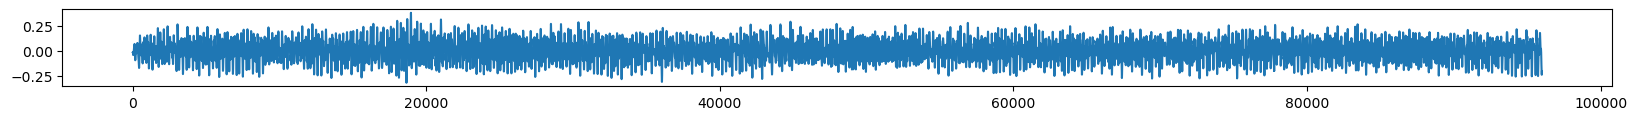

Finished epoch number 27 with a total of 10000 debug_seqs
 time: 2026-01-23 13:44:39.071195, epoch 28,  Loss: 0.3126
  Quantizer 0 Loss: 1.5441
  Quantizer 1 Loss: 3.6615
  Quantizer 2 Loss: 4.3554
  Quantizer 3 Loss: 4.5692
  Quantizer 4 Loss: 4.5549
  Quantizer 5 Loss: 4.5731
  Quantizer 6 Loss: 4.5830
  Quantizer 7 Loss: 4.5576
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


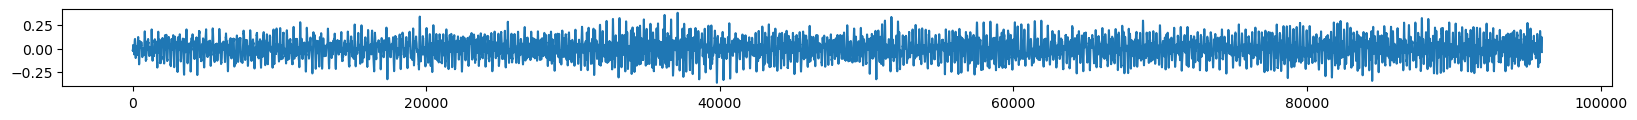

Finished epoch number 28 with a total of 10000 debug_seqs
 time: 2026-01-23 13:45:04.664073, epoch 29,  Loss: 0.2868
  Quantizer 0 Loss: 1.5053
  Quantizer 1 Loss: 3.5449
  Quantizer 2 Loss: 4.2794
  Quantizer 3 Loss: 4.5043
  Quantizer 4 Loss: 4.4992
  Quantizer 5 Loss: 4.5466
  Quantizer 6 Loss: 4.5717
  Quantizer 7 Loss: 4.5517
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


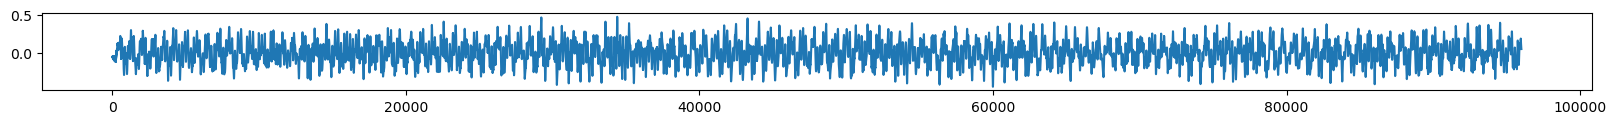

Finished epoch number 29 with a total of 10000 debug_seqs
 time: 2026-01-23 13:45:30.441364, epoch 30,  Loss: 0.2973
  Quantizer 0 Loss: 1.4865
  Quantizer 1 Loss: 3.4860
  Quantizer 2 Loss: 4.2253
  Quantizer 3 Loss: 4.4499
  Quantizer 4 Loss: 4.4657
  Quantizer 5 Loss: 4.5261
  Quantizer 6 Loss: 4.5550
  Quantizer 7 Loss: 4.5393
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


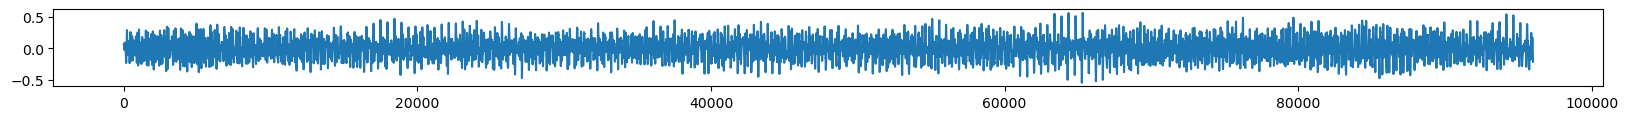

Finished epoch number 30 with a total of 10000 debug_seqs
 time: 2026-01-23 13:45:56.655253, epoch 31,  Loss: 0.2917
  Quantizer 0 Loss: 1.4800
  Quantizer 1 Loss: 3.4388
  Quantizer 2 Loss: 4.1849
  Quantizer 3 Loss: 4.4230
  Quantizer 4 Loss: 4.4524
  Quantizer 5 Loss: 4.4967
  Quantizer 6 Loss: 4.5385
  Quantizer 7 Loss: 4.5258
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


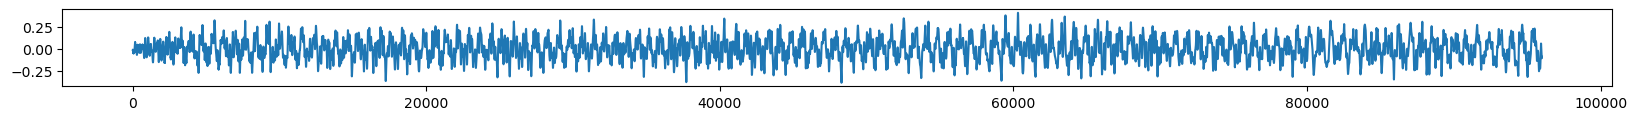

Finished epoch number 31 with a total of 10000 debug_seqs
 time: 2026-01-23 13:46:23.310866, epoch 32,  Loss: 0.2943
  Quantizer 0 Loss: 1.4543
  Quantizer 1 Loss: 3.4061
  Quantizer 2 Loss: 4.1581
  Quantizer 3 Loss: 4.3978
  Quantizer 4 Loss: 4.4230
  Quantizer 5 Loss: 4.4779
  Quantizer 6 Loss: 4.5277
  Quantizer 7 Loss: 4.5166
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


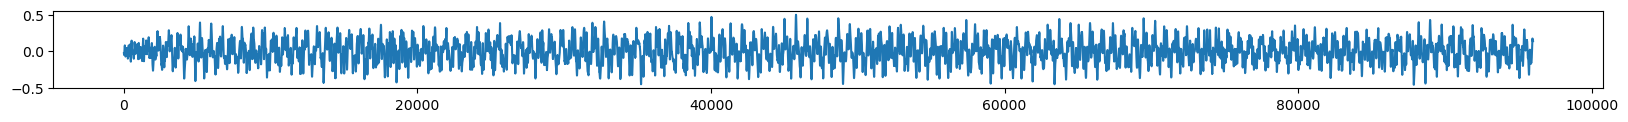

Finished epoch number 32 with a total of 10000 debug_seqs
 time: 2026-01-23 13:46:49.965456, epoch 33,  Loss: 0.3013
  Quantizer 0 Loss: 1.4497
  Quantizer 1 Loss: 3.4015
  Quantizer 2 Loss: 4.1510
  Quantizer 3 Loss: 4.4055
  Quantizer 4 Loss: 4.4399
  Quantizer 5 Loss: 4.4911
  Quantizer 6 Loss: 4.5397
  Quantizer 7 Loss: 4.5274
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


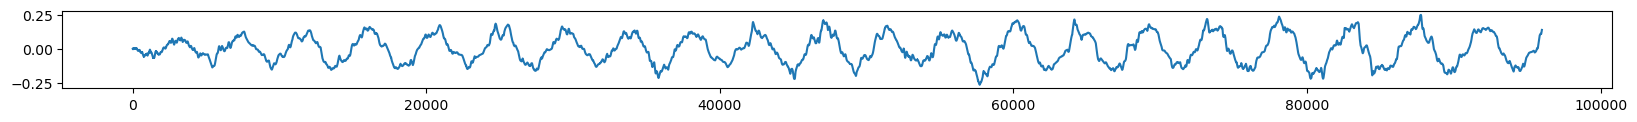

Finished epoch number 33 with a total of 10000 debug_seqs
 time: 2026-01-23 13:47:16.595349, epoch 34,  Loss: 0.2912
  Quantizer 0 Loss: 1.4380
  Quantizer 1 Loss: 3.3798
  Quantizer 2 Loss: 4.1362
  Quantizer 3 Loss: 4.3799
  Quantizer 4 Loss: 4.4084
  Quantizer 5 Loss: 4.4734
  Quantizer 6 Loss: 4.5197
  Quantizer 7 Loss: 4.5123
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


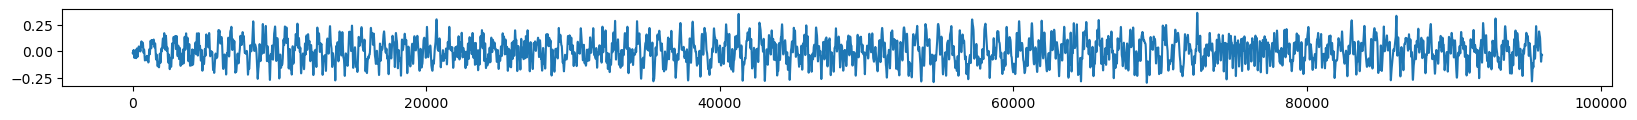

Finished epoch number 34 with a total of 10000 debug_seqs
 time: 2026-01-23 13:47:43.726406, epoch 35,  Loss: 0.2885
  Quantizer 0 Loss: 1.4321
  Quantizer 1 Loss: 3.3566
  Quantizer 2 Loss: 4.1135
  Quantizer 3 Loss: 4.3659
  Quantizer 4 Loss: 4.3922
  Quantizer 5 Loss: 4.4615
  Quantizer 6 Loss: 4.5164
  Quantizer 7 Loss: 4.5075
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


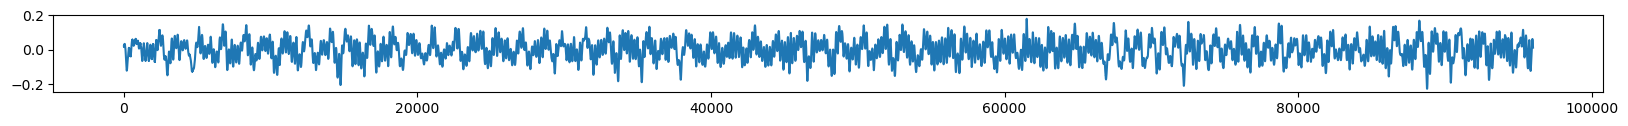

Finished epoch number 35 with a total of 10000 debug_seqs
 time: 2026-01-23 13:48:10.898621, epoch 36,  Loss: 0.2847
  Quantizer 0 Loss: 1.4178
  Quantizer 1 Loss: 3.3345
  Quantizer 2 Loss: 4.0977
  Quantizer 3 Loss: 4.3505
  Quantizer 4 Loss: 4.3799
  Quantizer 5 Loss: 4.4514
  Quantizer 6 Loss: 4.5026
  Quantizer 7 Loss: 4.4934
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


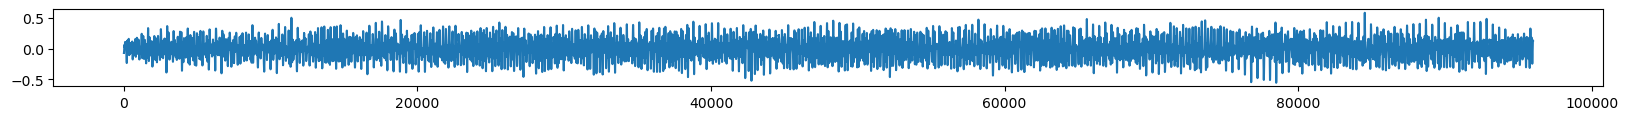

Finished epoch number 36 with a total of 10000 debug_seqs
 time: 2026-01-23 13:48:37.922222, epoch 37,  Loss: 0.2837
  Quantizer 0 Loss: 1.4156
  Quantizer 1 Loss: 3.3394
  Quantizer 2 Loss: 4.1047
  Quantizer 3 Loss: 4.3652
  Quantizer 4 Loss: 4.4019
  Quantizer 5 Loss: 4.4691
  Quantizer 6 Loss: 4.5252
  Quantizer 7 Loss: 4.5164
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


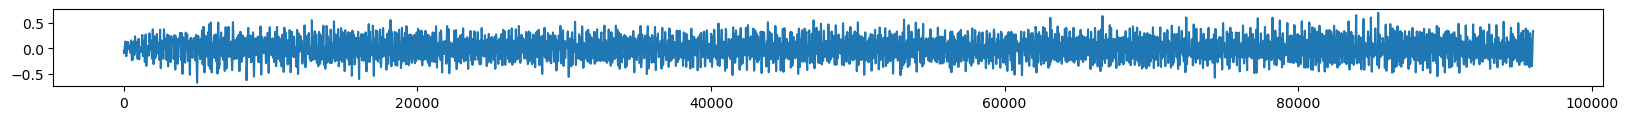

Finished epoch number 37 with a total of 10000 debug_seqs
 time: 2026-01-23 13:49:05.177198, epoch 38,  Loss: 0.2869
  Quantizer 0 Loss: 1.4087
  Quantizer 1 Loss: 3.3196
  Quantizer 2 Loss: 4.0910
  Quantizer 3 Loss: 4.3417
  Quantizer 4 Loss: 4.3759
  Quantizer 5 Loss: 4.4473
  Quantizer 6 Loss: 4.5020
  Quantizer 7 Loss: 4.4978
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


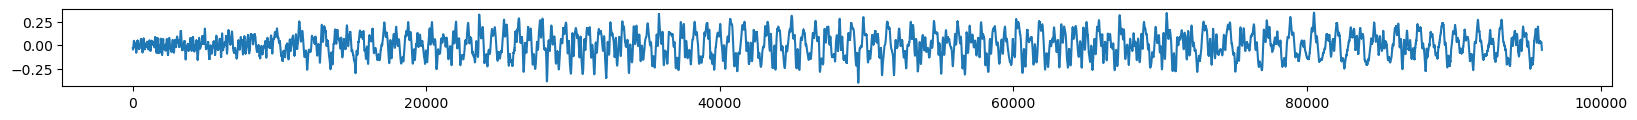

Finished epoch number 38 with a total of 10000 debug_seqs
 time: 2026-01-23 13:49:32.546304, epoch 39,  Loss: 0.2920
  Quantizer 0 Loss: 1.4008
  Quantizer 1 Loss: 3.3199
  Quantizer 2 Loss: 4.0993
  Quantizer 3 Loss: 4.3588
  Quantizer 4 Loss: 4.3975
  Quantizer 5 Loss: 4.4645
  Quantizer 6 Loss: 4.5214
  Quantizer 7 Loss: 4.5208
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


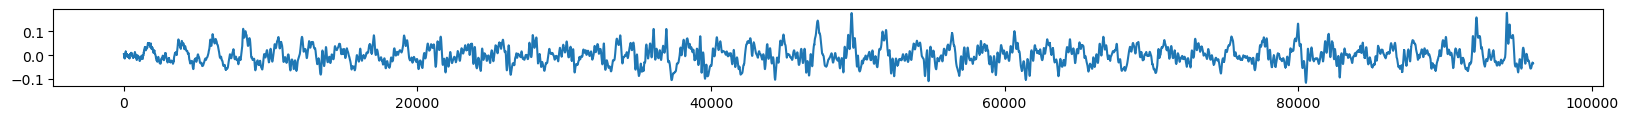

Finished epoch number 39 with a total of 10000 debug_seqs
 time: 2026-01-23 13:49:59.970208, epoch 40,  Loss: 0.2819
  Quantizer 0 Loss: 1.3968
  Quantizer 1 Loss: 3.3131
  Quantizer 2 Loss: 4.0800
  Quantizer 3 Loss: 4.3414
  Quantizer 4 Loss: 4.3834
  Quantizer 5 Loss: 4.4481
  Quantizer 6 Loss: 4.5064
  Quantizer 7 Loss: 4.5107
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


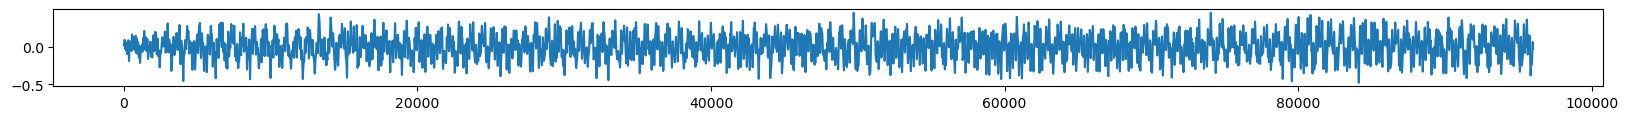

Finished epoch number 40 with a total of 10000 debug_seqs
 time: 2026-01-23 13:50:27.816737, epoch 41,  Loss: 0.2779
  Quantizer 0 Loss: 1.3910
  Quantizer 1 Loss: 3.2928
  Quantizer 2 Loss: 4.0784
  Quantizer 3 Loss: 4.3317
  Quantizer 4 Loss: 4.3660
  Quantizer 5 Loss: 4.4369
  Quantizer 6 Loss: 4.4956
  Quantizer 7 Loss: 4.4984
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


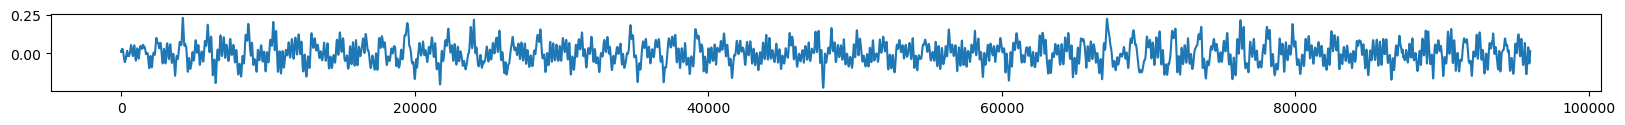

Finished epoch number 41 with a total of 10000 debug_seqs
 time: 2026-01-23 13:50:55.700941, epoch 42,  Loss: 0.2873
  Quantizer 0 Loss: 1.3792
  Quantizer 1 Loss: 3.2796
  Quantizer 2 Loss: 4.0599
  Quantizer 3 Loss: 4.3319
  Quantizer 4 Loss: 4.3664
  Quantizer 5 Loss: 4.4321
  Quantizer 6 Loss: 4.4929
  Quantizer 7 Loss: 4.4947
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


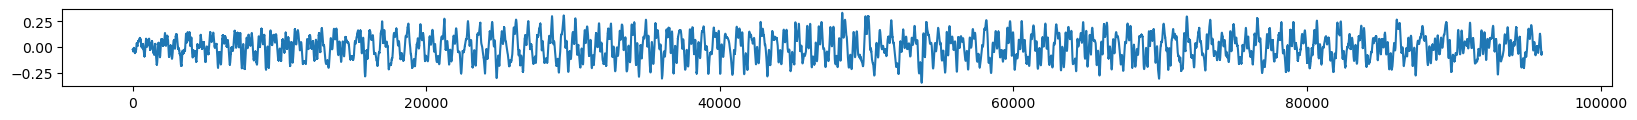

Finished epoch number 42 with a total of 10000 debug_seqs
 time: 2026-01-23 13:51:23.574553, epoch 43,  Loss: 0.2829
  Quantizer 0 Loss: 1.3759
  Quantizer 1 Loss: 3.2706
  Quantizer 2 Loss: 4.0593
  Quantizer 3 Loss: 4.3176
  Quantizer 4 Loss: 4.3568
  Quantizer 5 Loss: 4.4226
  Quantizer 6 Loss: 4.4890
  Quantizer 7 Loss: 4.4888
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


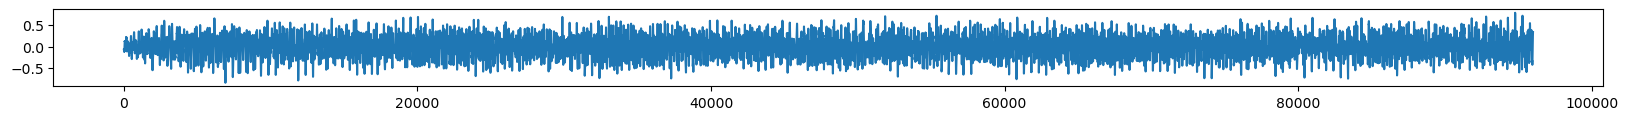

Finished epoch number 43 with a total of 10000 debug_seqs
 time: 2026-01-23 13:51:51.466931, epoch 44,  Loss: 0.2794
  Quantizer 0 Loss: 1.3669
  Quantizer 1 Loss: 3.2682
  Quantizer 2 Loss: 4.0471
  Quantizer 3 Loss: 4.3184
  Quantizer 4 Loss: 4.3592
  Quantizer 5 Loss: 4.4281
  Quantizer 6 Loss: 4.4872
  Quantizer 7 Loss: 4.4871
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


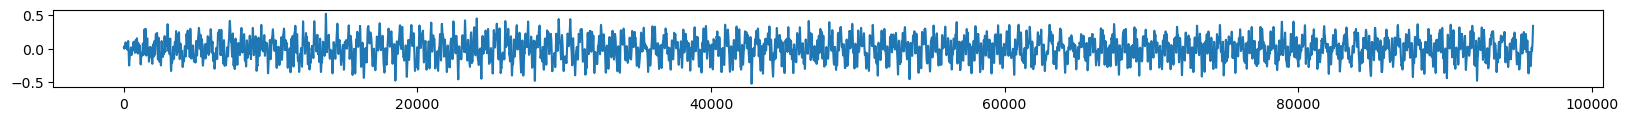

Finished epoch number 44 with a total of 10000 debug_seqs
 time: 2026-01-23 13:52:19.316184, epoch 45,  Loss: 0.2859
  Quantizer 0 Loss: 1.3570
  Quantizer 1 Loss: 3.2604
  Quantizer 2 Loss: 4.0488
  Quantizer 3 Loss: 4.3079
  Quantizer 4 Loss: 4.3627
  Quantizer 5 Loss: 4.4246
  Quantizer 6 Loss: 4.4925
  Quantizer 7 Loss: 4.4874
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


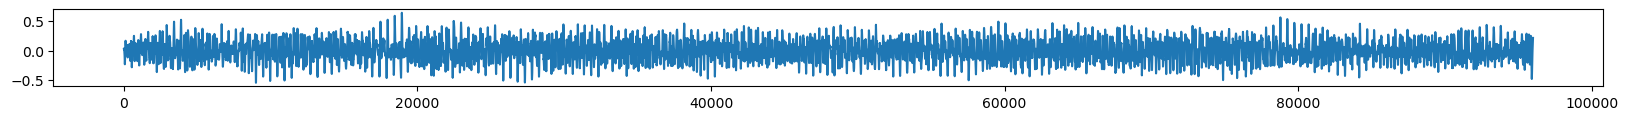

Finished epoch number 45 with a total of 10000 debug_seqs
 time: 2026-01-23 13:52:47.583390, epoch 46,  Loss: 0.2889
  Quantizer 0 Loss: 1.3584
  Quantizer 1 Loss: 3.2482
  Quantizer 2 Loss: 4.0411
  Quantizer 3 Loss: 4.3040
  Quantizer 4 Loss: 4.3482
  Quantizer 5 Loss: 4.4172
  Quantizer 6 Loss: 4.4808
  Quantizer 7 Loss: 4.4777
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


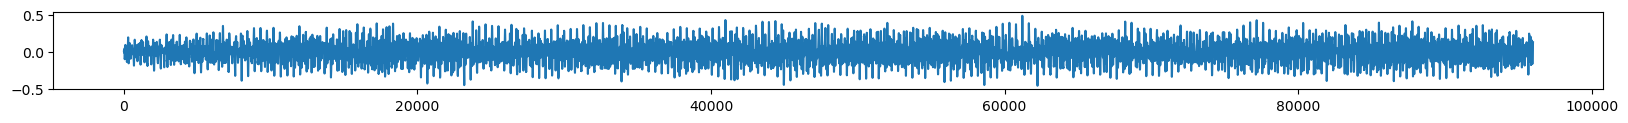

Finished epoch number 46 with a total of 10000 debug_seqs
 time: 2026-01-23 13:53:15.641259, epoch 47,  Loss: 0.2885
  Quantizer 0 Loss: 1.3634
  Quantizer 1 Loss: 3.2586
  Quantizer 2 Loss: 4.0415
  Quantizer 3 Loss: 4.3097
  Quantizer 4 Loss: 4.3536
  Quantizer 5 Loss: 4.4199
  Quantizer 6 Loss: 4.4848
  Quantizer 7 Loss: 4.4923
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


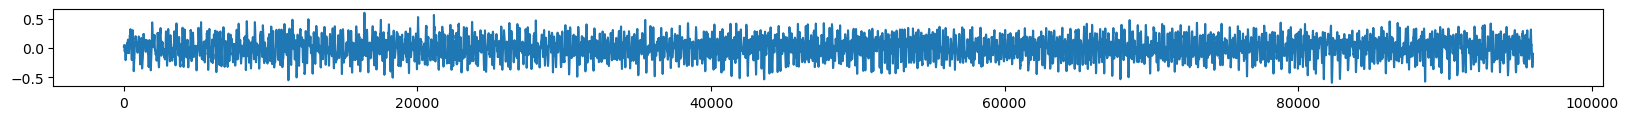

Finished epoch number 47 with a total of 10000 debug_seqs
 time: 2026-01-23 13:53:44.635771, epoch 48,  Loss: 0.2824
  Quantizer 0 Loss: 1.3532
  Quantizer 1 Loss: 3.2471
  Quantizer 2 Loss: 4.0415
  Quantizer 3 Loss: 4.3086
  Quantizer 4 Loss: 4.3515
  Quantizer 5 Loss: 4.4191
  Quantizer 6 Loss: 4.4846
  Quantizer 7 Loss: 4.4841
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


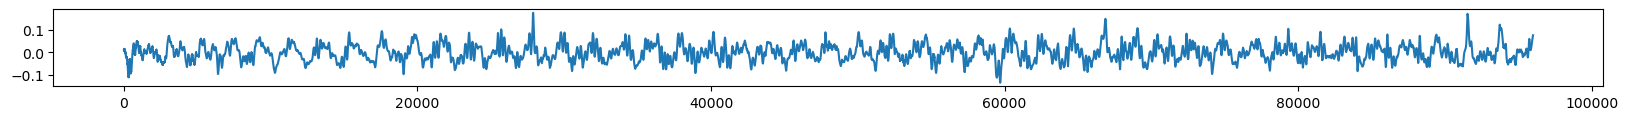

Finished epoch number 48 with a total of 10000 debug_seqs
 time: 2026-01-23 13:54:12.927498, epoch 49,  Loss: 0.2793
  Quantizer 0 Loss: 1.3543
  Quantizer 1 Loss: 3.2501
  Quantizer 2 Loss: 4.0401
  Quantizer 3 Loss: 4.3084
  Quantizer 4 Loss: 4.3549
  Quantizer 5 Loss: 4.4215
  Quantizer 6 Loss: 4.4860
  Quantizer 7 Loss: 4.4874
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


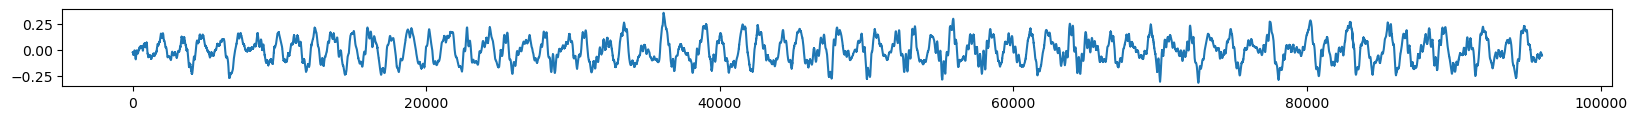

Finished epoch number 49 with a total of 10000 debug_seqs
 time: 2026-01-23 13:54:41.565402, epoch 50,  Loss: 0.2919
  Quantizer 0 Loss: 1.3451
  Quantizer 1 Loss: 3.2358
  Quantizer 2 Loss: 4.0388
  Quantizer 3 Loss: 4.3092
  Quantizer 4 Loss: 4.3593
  Quantizer 5 Loss: 4.4284
  Quantizer 6 Loss: 4.4935
  Quantizer 7 Loss: 4.4914
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


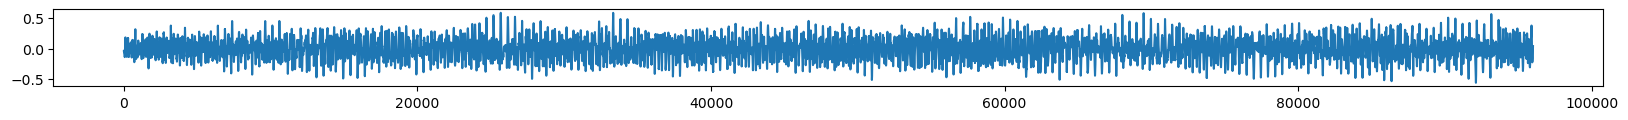

Saved checkpoint at epoch 50
Finished epoch number 50 with a total of 10000 debug_seqs
 time: 2026-01-23 13:55:04.904750, epoch 51,  Loss: 0.2445
  Quantizer 0 Loss: 1.3189
  Quantizer 1 Loss: 2.6658
  Quantizer 2 Loss: 3.3689
  Quantizer 3 Loss: 3.6973
  Quantizer 4 Loss: 3.8069
  Quantizer 5 Loss: 3.8781
  Quantizer 6 Loss: 3.9839
  Quantizer 7 Loss: 3.9889
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


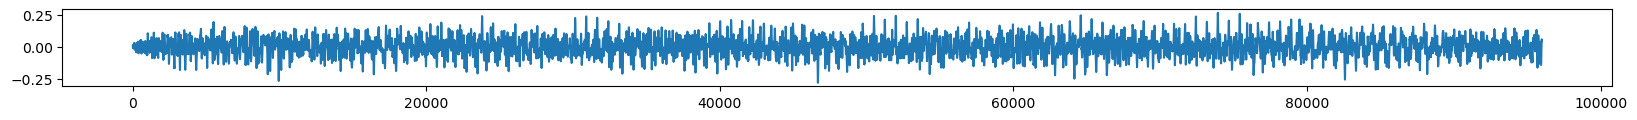

Finished epoch number 51 with a total of 10000 debug_seqs
 time: 2026-01-23 13:55:27.269915, epoch 52,  Loss: 0.2388
  Quantizer 0 Loss: 1.3271
  Quantizer 1 Loss: 2.6198
  Quantizer 2 Loss: 3.2670
  Quantizer 3 Loss: 3.5912
  Quantizer 4 Loss: 3.7203
  Quantizer 5 Loss: 3.7928
  Quantizer 6 Loss: 3.9134
  Quantizer 7 Loss: 3.9286
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


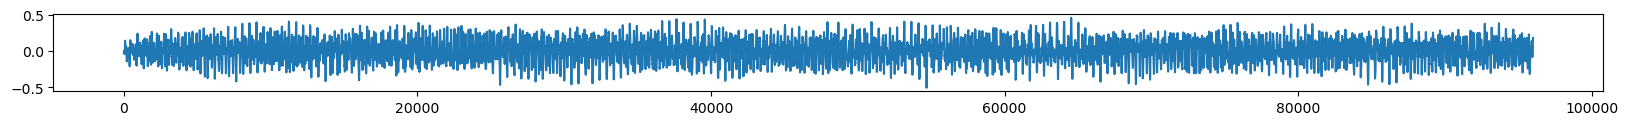

Finished epoch number 52 with a total of 10000 debug_seqs
 time: 2026-01-23 13:55:49.825225, epoch 53,  Loss: 0.2367
  Quantizer 0 Loss: 1.3241
  Quantizer 1 Loss: 2.5899
  Quantizer 2 Loss: 3.2153
  Quantizer 3 Loss: 3.5365
  Quantizer 4 Loss: 3.6634
  Quantizer 5 Loss: 3.7433
  Quantizer 6 Loss: 3.8607
  Quantizer 7 Loss: 3.8792
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


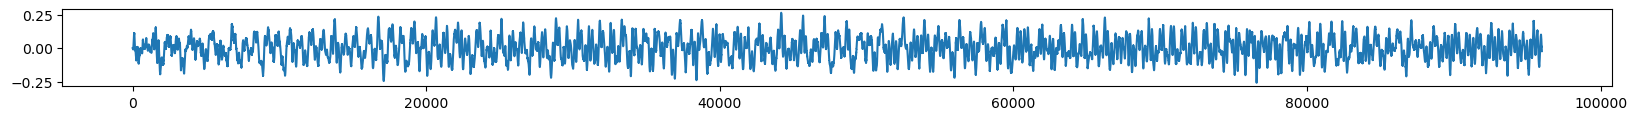

Finished epoch number 53 with a total of 10000 debug_seqs
 time: 2026-01-23 13:56:12.126635, epoch 54,  Loss: 0.2336
  Quantizer 0 Loss: 1.3205
  Quantizer 1 Loss: 2.5715
  Quantizer 2 Loss: 3.1871
  Quantizer 3 Loss: 3.5103
  Quantizer 4 Loss: 3.6470
  Quantizer 5 Loss: 3.7217
  Quantizer 6 Loss: 3.8439
  Quantizer 7 Loss: 3.8664
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


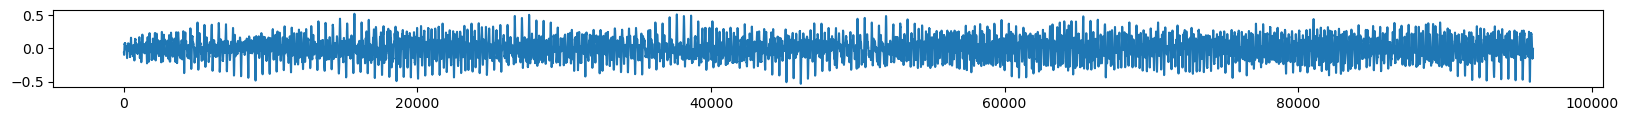

Finished epoch number 54 with a total of 10000 debug_seqs
 time: 2026-01-23 13:56:34.422299, epoch 55,  Loss: 0.2469
  Quantizer 0 Loss: 1.3258
  Quantizer 1 Loss: 2.5650
  Quantizer 2 Loss: 3.1778
  Quantizer 3 Loss: 3.4997
  Quantizer 4 Loss: 3.6353
  Quantizer 5 Loss: 3.7063
  Quantizer 6 Loss: 3.8302
  Quantizer 7 Loss: 3.8480
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


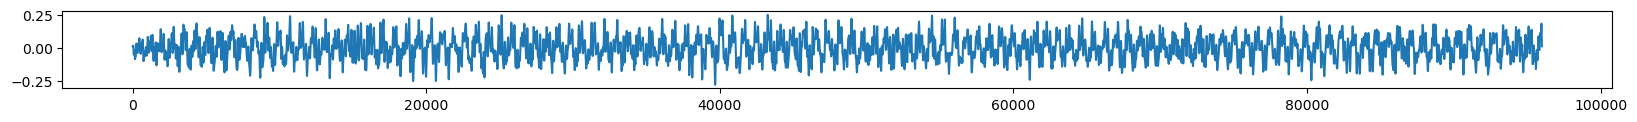

Finished epoch number 55 with a total of 10000 debug_seqs
 time: 2026-01-23 13:56:57.239671, epoch 56,  Loss: 0.2309
  Quantizer 0 Loss: 1.3172
  Quantizer 1 Loss: 2.5554
  Quantizer 2 Loss: 3.1648
  Quantizer 3 Loss: 3.4904
  Quantizer 4 Loss: 3.6240
  Quantizer 5 Loss: 3.7059
  Quantizer 6 Loss: 3.8250
  Quantizer 7 Loss: 3.8498
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


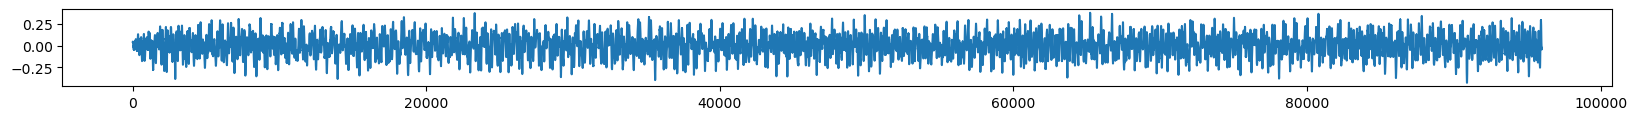

Finished epoch number 56 with a total of 10000 debug_seqs
 time: 2026-01-23 13:57:19.592472, epoch 57,  Loss: 0.2330
  Quantizer 0 Loss: 1.3061
  Quantizer 1 Loss: 2.5393
  Quantizer 2 Loss: 3.1510
  Quantizer 3 Loss: 3.4794
  Quantizer 4 Loss: 3.6172
  Quantizer 5 Loss: 3.6989
  Quantizer 6 Loss: 3.8217
  Quantizer 7 Loss: 3.8454
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


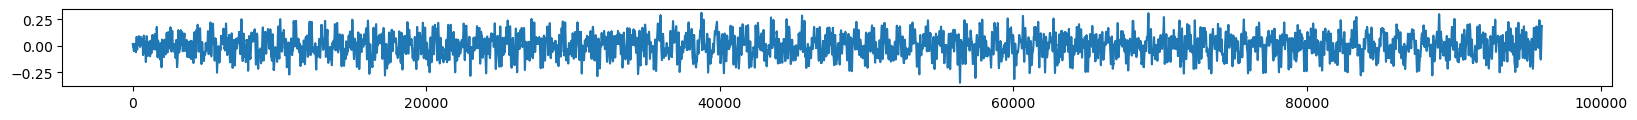

Finished epoch number 57 with a total of 10000 debug_seqs
 time: 2026-01-23 13:57:41.964559, epoch 58,  Loss: 0.2309
  Quantizer 0 Loss: 1.2989
  Quantizer 1 Loss: 2.5205
  Quantizer 2 Loss: 3.1261
  Quantizer 3 Loss: 3.4614
  Quantizer 4 Loss: 3.5994
  Quantizer 5 Loss: 3.6801
  Quantizer 6 Loss: 3.8064
  Quantizer 7 Loss: 3.8274
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


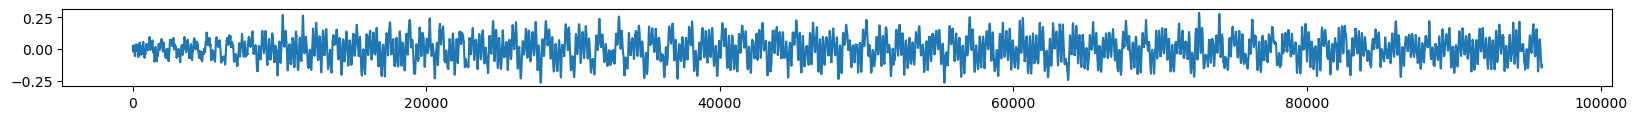

Finished epoch number 58 with a total of 10000 debug_seqs
 time: 2026-01-23 13:58:04.337935, epoch 59,  Loss: 0.2294
  Quantizer 0 Loss: 1.2963
  Quantizer 1 Loss: 2.5159
  Quantizer 2 Loss: 3.1235
  Quantizer 3 Loss: 3.4494
  Quantizer 4 Loss: 3.5950
  Quantizer 5 Loss: 3.6751
  Quantizer 6 Loss: 3.7960
  Quantizer 7 Loss: 3.8191
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


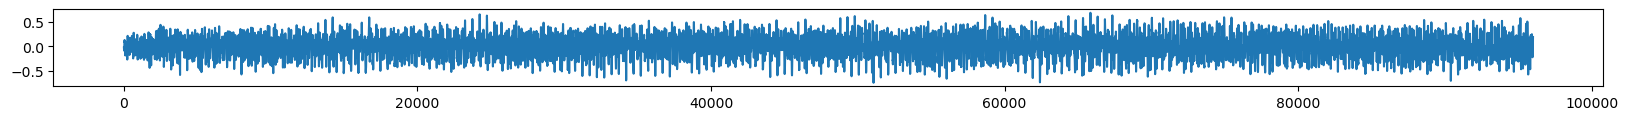

Finished epoch number 59 with a total of 10000 debug_seqs
 time: 2026-01-23 13:58:26.586945, epoch 60,  Loss: 0.2328
  Quantizer 0 Loss: 1.3031
  Quantizer 1 Loss: 2.5184
  Quantizer 2 Loss: 3.1258
  Quantizer 3 Loss: 3.4533
  Quantizer 4 Loss: 3.5980
  Quantizer 5 Loss: 3.6798
  Quantizer 6 Loss: 3.8009
  Quantizer 7 Loss: 3.8292
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


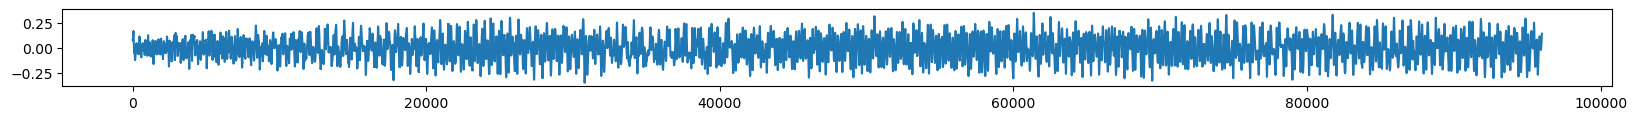

Finished epoch number 60 with a total of 10000 debug_seqs
 time: 2026-01-23 13:58:49.018281, epoch 61,  Loss: 0.2269
  Quantizer 0 Loss: 1.3022
  Quantizer 1 Loss: 2.5133
  Quantizer 2 Loss: 3.1149
  Quantizer 3 Loss: 3.4482
  Quantizer 4 Loss: 3.5886
  Quantizer 5 Loss: 3.6682
  Quantizer 6 Loss: 3.7939
  Quantizer 7 Loss: 3.8186
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


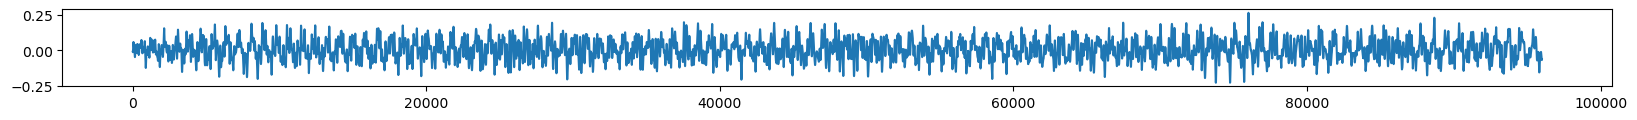

Finished epoch number 61 with a total of 10000 debug_seqs
 time: 2026-01-23 13:59:11.625670, epoch 62,  Loss: 0.2330
  Quantizer 0 Loss: 1.3020
  Quantizer 1 Loss: 2.5097
  Quantizer 2 Loss: 3.1109
  Quantizer 3 Loss: 3.4518
  Quantizer 4 Loss: 3.6009
  Quantizer 5 Loss: 3.6823
  Quantizer 6 Loss: 3.8056
  Quantizer 7 Loss: 3.8283
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


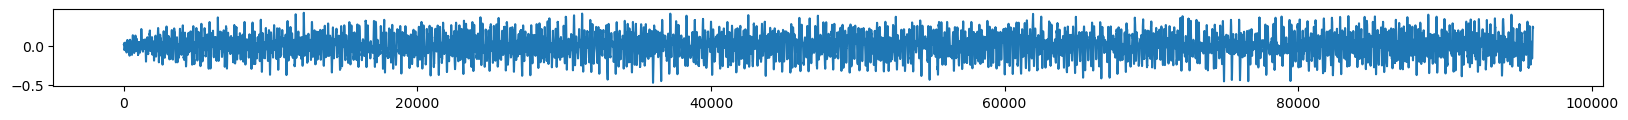

Finished epoch number 62 with a total of 10000 debug_seqs
 time: 2026-01-23 13:59:34.252278, epoch 63,  Loss: 0.2322
  Quantizer 0 Loss: 1.2845
  Quantizer 1 Loss: 2.4871
  Quantizer 2 Loss: 3.0849
  Quantizer 3 Loss: 3.4234
  Quantizer 4 Loss: 3.5665
  Quantizer 5 Loss: 3.6487
  Quantizer 6 Loss: 3.7781
  Quantizer 7 Loss: 3.7973
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


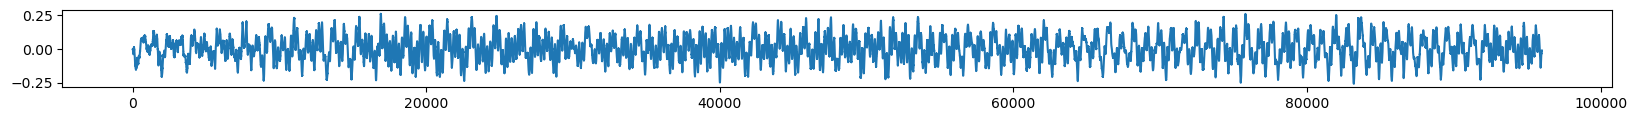

Finished epoch number 63 with a total of 10000 debug_seqs
 time: 2026-01-23 13:59:57.166393, epoch 64,  Loss: 0.2225
  Quantizer 0 Loss: 1.2881
  Quantizer 1 Loss: 2.4878
  Quantizer 2 Loss: 3.0870
  Quantizer 3 Loss: 3.4216
  Quantizer 4 Loss: 3.5773
  Quantizer 5 Loss: 3.6549
  Quantizer 6 Loss: 3.7879
  Quantizer 7 Loss: 3.8114
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


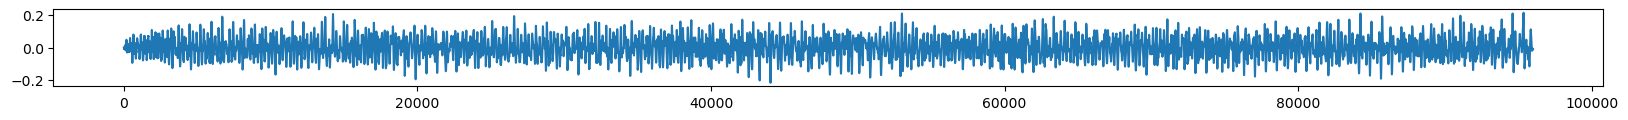

Finished epoch number 64 with a total of 10000 debug_seqs
 time: 2026-01-23 14:00:20.024008, epoch 65,  Loss: 0.2316
  Quantizer 0 Loss: 1.2756
  Quantizer 1 Loss: 2.4684
  Quantizer 2 Loss: 3.0692
  Quantizer 3 Loss: 3.4020
  Quantizer 4 Loss: 3.5550
  Quantizer 5 Loss: 3.6381
  Quantizer 6 Loss: 3.7719
  Quantizer 7 Loss: 3.7914
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


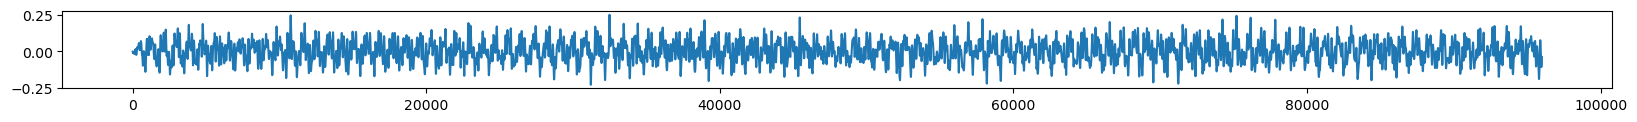

Finished epoch number 65 with a total of 10000 debug_seqs
 time: 2026-01-23 14:00:43.050785, epoch 66,  Loss: 0.2299
  Quantizer 0 Loss: 1.2857
  Quantizer 1 Loss: 2.4766
  Quantizer 2 Loss: 3.0768
  Quantizer 3 Loss: 3.4123
  Quantizer 4 Loss: 3.5645
  Quantizer 5 Loss: 3.6481
  Quantizer 6 Loss: 3.7749
  Quantizer 7 Loss: 3.8013
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


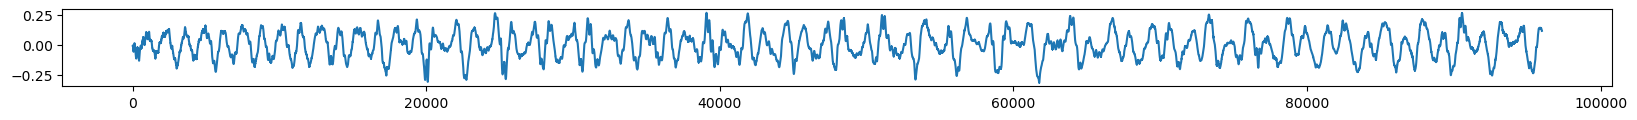

Finished epoch number 66 with a total of 10000 debug_seqs
 time: 2026-01-23 14:01:05.788302, epoch 67,  Loss: 0.2339
  Quantizer 0 Loss: 1.2757
  Quantizer 1 Loss: 2.4691
  Quantizer 2 Loss: 3.0702
  Quantizer 3 Loss: 3.4082
  Quantizer 4 Loss: 3.5582
  Quantizer 5 Loss: 3.6458
  Quantizer 6 Loss: 3.7741
  Quantizer 7 Loss: 3.7951
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


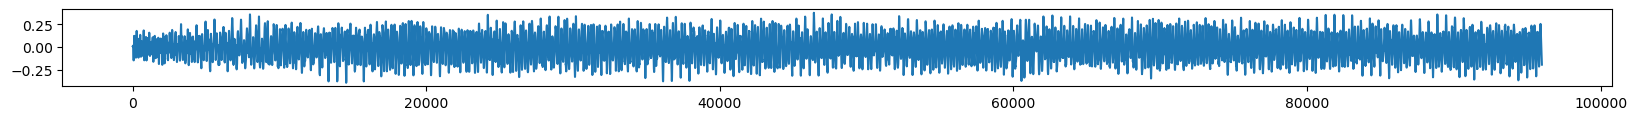

Finished epoch number 67 with a total of 10000 debug_seqs
 time: 2026-01-23 14:01:28.689389, epoch 68,  Loss: 0.2262
  Quantizer 0 Loss: 1.2692
  Quantizer 1 Loss: 2.4513
  Quantizer 2 Loss: 3.0533
  Quantizer 3 Loss: 3.3937
  Quantizer 4 Loss: 3.5525
  Quantizer 5 Loss: 3.6315
  Quantizer 6 Loss: 3.7654
  Quantizer 7 Loss: 3.7913
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


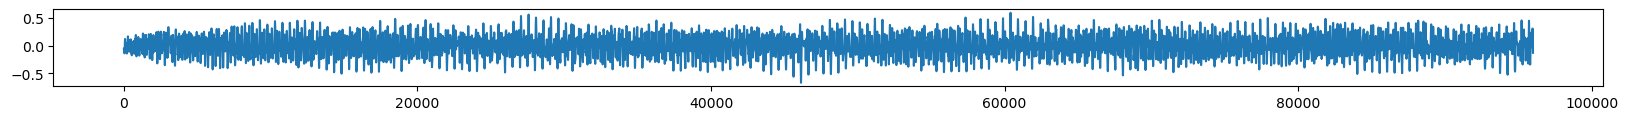

Finished epoch number 68 with a total of 10000 debug_seqs
 time: 2026-01-23 14:01:51.011607, epoch 69,  Loss: 0.2313
  Quantizer 0 Loss: 1.2702
  Quantizer 1 Loss: 2.4522
  Quantizer 2 Loss: 3.0516
  Quantizer 3 Loss: 3.3967
  Quantizer 4 Loss: 3.5502
  Quantizer 5 Loss: 3.6309
  Quantizer 6 Loss: 3.7594
  Quantizer 7 Loss: 3.7844
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


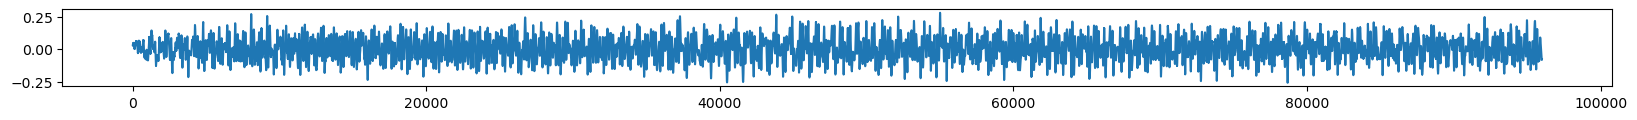

Finished epoch number 69 with a total of 10000 debug_seqs
 time: 2026-01-23 14:02:13.723400, epoch 70,  Loss: 0.2304
  Quantizer 0 Loss: 1.2778
  Quantizer 1 Loss: 2.4697
  Quantizer 2 Loss: 3.0640
  Quantizer 3 Loss: 3.4032
  Quantizer 4 Loss: 3.5596
  Quantizer 5 Loss: 3.6421
  Quantizer 6 Loss: 3.7711
  Quantizer 7 Loss: 3.7961
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


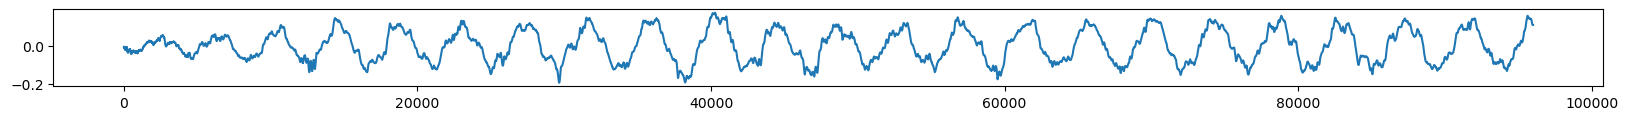

Finished epoch number 70 with a total of 10000 debug_seqs
 time: 2026-01-23 14:02:36.623425, epoch 71,  Loss: 0.2323
  Quantizer 0 Loss: 1.2635
  Quantizer 1 Loss: 2.4309
  Quantizer 2 Loss: 3.0271
  Quantizer 3 Loss: 3.3695
  Quantizer 4 Loss: 3.5234
  Quantizer 5 Loss: 3.6135
  Quantizer 6 Loss: 3.7462
  Quantizer 7 Loss: 3.7672
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


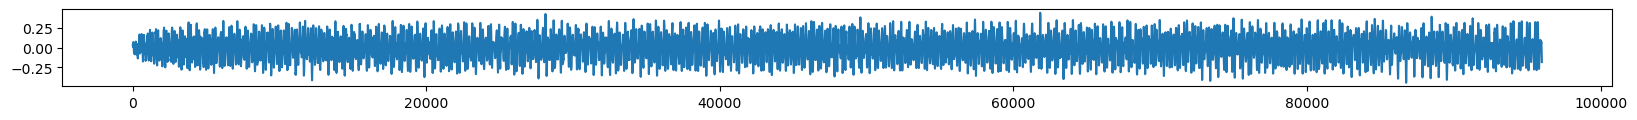

Finished epoch number 71 with a total of 10000 debug_seqs
 time: 2026-01-23 14:02:59.441069, epoch 72,  Loss: 0.2291
  Quantizer 0 Loss: 1.2562
  Quantizer 1 Loss: 2.4368
  Quantizer 2 Loss: 3.0284
  Quantizer 3 Loss: 3.3698
  Quantizer 4 Loss: 3.5271
  Quantizer 5 Loss: 3.6165
  Quantizer 6 Loss: 3.7542
  Quantizer 7 Loss: 3.7714
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


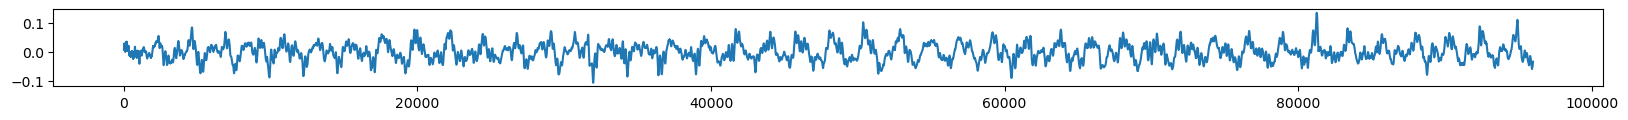

Finished epoch number 72 with a total of 10000 debug_seqs
 time: 2026-01-23 14:03:22.548387, epoch 73,  Loss: 0.2214
  Quantizer 0 Loss: 1.2660
  Quantizer 1 Loss: 2.4408
  Quantizer 2 Loss: 3.0329
  Quantizer 3 Loss: 3.3765
  Quantizer 4 Loss: 3.5314
  Quantizer 5 Loss: 3.6271
  Quantizer 6 Loss: 3.7525
  Quantizer 7 Loss: 3.7815
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


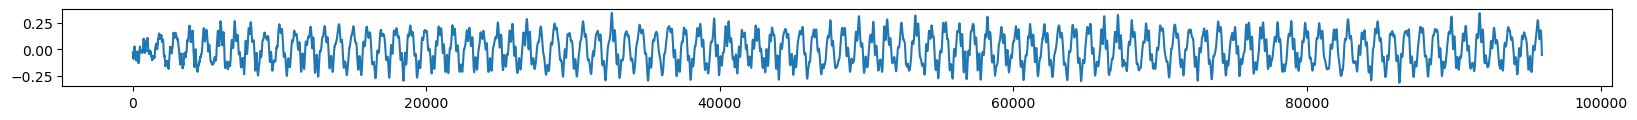

Finished epoch number 73 with a total of 10000 debug_seqs
 time: 2026-01-23 14:03:45.438865, epoch 74,  Loss: 0.2245
  Quantizer 0 Loss: 1.2543
  Quantizer 1 Loss: 2.4200
  Quantizer 2 Loss: 3.0157
  Quantizer 3 Loss: 3.3524
  Quantizer 4 Loss: 3.5181
  Quantizer 5 Loss: 3.6076
  Quantizer 6 Loss: 3.7406
  Quantizer 7 Loss: 3.7629
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


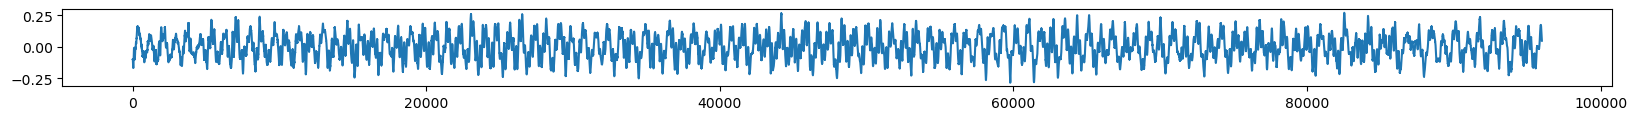

Finished epoch number 74 with a total of 10000 debug_seqs
 time: 2026-01-23 14:04:08.135397, epoch 75,  Loss: 0.2252
  Quantizer 0 Loss: 1.2492
  Quantizer 1 Loss: 2.4197
  Quantizer 2 Loss: 3.0196
  Quantizer 3 Loss: 3.3548
  Quantizer 4 Loss: 3.5259
  Quantizer 5 Loss: 3.6118
  Quantizer 6 Loss: 3.7427
  Quantizer 7 Loss: 3.7748
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


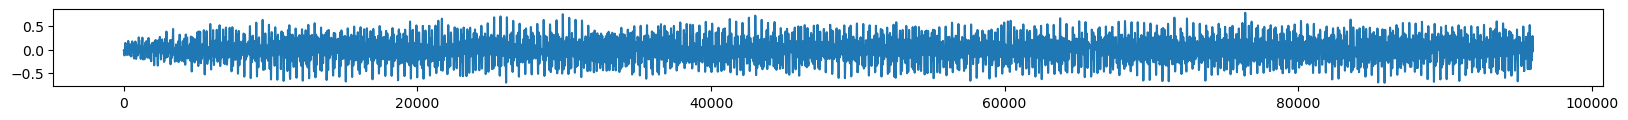

Saved checkpoint at epoch 75
Finished epoch number 75 with a total of 10000 debug_seqs
 time: 2026-01-23 14:04:37.390615, epoch 76,  Loss: 0.2998
  Quantizer 0 Loss: 1.4374
  Quantizer 1 Loss: 3.9618
  Quantizer 2 Loss: 4.6908
  Quantizer 3 Loss: 4.8244
  Quantizer 4 Loss: 4.7125
  Quantizer 5 Loss: 4.6625
  Quantizer 6 Loss: 4.6487
  Quantizer 7 Loss: 4.6151
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


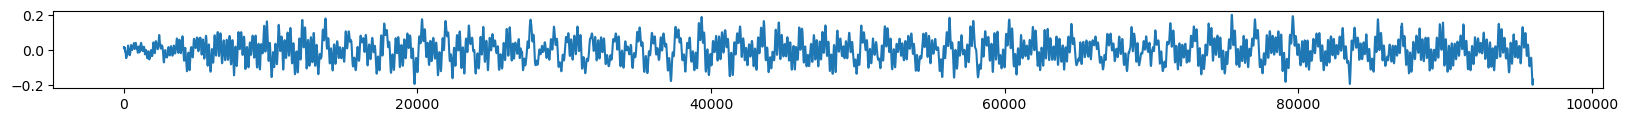

Training time taken: 0:20:48
Saved checkpoint at epoch 76


'output/20260123_114246_engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_newprep/checkpoints/last_checkpoint.pt'

In [16]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,enc_model,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


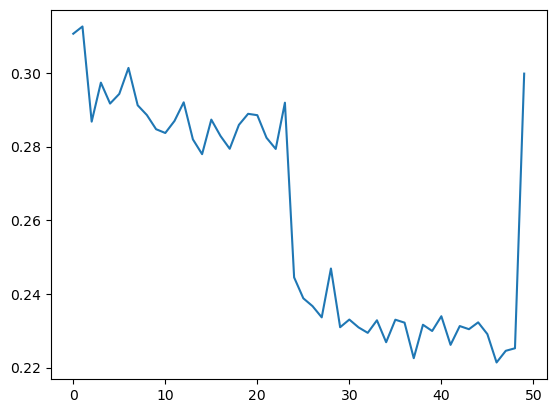

In [17]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

In [18]:
list_of_losses

[0.31062667846679687,
 0.312593994140625,
 0.2867626190185547,
 0.29734806060791014,
 0.2916648292541504,
 0.2942852783203125,
 0.3013439559936523,
 0.29120138168334964,
 0.2885428237915039,
 0.2847010612487793,
 0.2836748695373535,
 0.28694570541381836,
 0.2919988441467285,
 0.28194725036621093,
 0.2779234504699707,
 0.2873088264465332,
 0.28286582946777344,
 0.27938716888427734,
 0.2858760833740234,
 0.2888819122314453,
 0.28850841522216797,
 0.2823782730102539,
 0.27934310913085936,
 0.2919013595581055,
 0.24446630477905273,
 0.23879003524780273,
 0.23666828155517577,
 0.23361705780029296,
 0.24688581466674805,
 0.2309395980834961,
 0.23301803588867187,
 0.2308963394165039,
 0.2294139289855957,
 0.23282384872436523,
 0.2268701171875,
 0.23297885894775391,
 0.23218193054199218,
 0.22253578186035156,
 0.2316088104248047,
 0.22991712570190428,
 0.23392473220825194,
 0.22615209579467774,
 0.2312565803527832,
 0.23040563583374024,
 0.23226015090942384,
 0.22907060623168946,
 0.2213686180